# Nowcasting du PIB américain — Notebook de synthèse

**Auteur :** Kondi Kaled ABODJI — *kondi.kaled.abodji@gmail.com*  
**Challenge :** QuantCube Technology — Septembre 2026

---

Ce notebook reproduit **de bout en bout** l'analyse présentée dans le rapport PDF (`reports/rapport_nowcasting.pdf`). Il est indépendant des 8 notebooks détaillés (`01_*` à `08_*`) qui documentent le raisonnement pas-à-pas.

**Question :** peut-on estimer le PIB réel américain du trimestre courant avant sa publication officielle, à partir d'indicateurs mensuels et hebdomadaires FRED ?

**Approche :** équation de pont (*bridge equation*) — les indicateurs infra-trimestriels sont agrégés en trimestriel, puis utilisés comme régresseurs pour prédire le PIB. Trois variantes de régression (OLS, Ridge, ElasticNet) + PCA sont comparées à deux références (Naive, AR(1)), avec un backtest en fenêtre extensible sans look-ahead bias.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from quantcube_challenge.data import FRED_SERIES, fetch_series
from quantcube_challenge.evaluation import (
    BacktestResult,
    ExpandingWindow,
    diebold_mariano,
    mae,
    ragged_x_test,
    rmse,
)
from quantcube_challenge.models import (
    AR1,
    BridgeEquation,
    ElasticNetBridge,
    NaiveLastValue,
    PCABridge,
    RidgeBridge,
)
from quantcube_challenge.preprocessing import Diff, LogDiff, to_annualized_growth
from quantcube_challenge.preprocessing.aggregation import MeanAggregation

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100

## 1. Cible et données

**Cible :** PIB réel US (`GDPC1`), transformé en **taux de croissance trimestriel annualisé** (convention BEA/Fed). Le choix du taux — plutôt que du niveau — est motivé par la stationnarité (évite les régressions fallacieuses) et l'interprétabilité économique.

**Régresseurs :** 8 indicateurs FRED couvrant les 4 dimensions du cycle (activité, emploi, consommation, conditions financières). Les séries macroéconomiques sont utilisées dans leur version **désaisonnalisée (SA)**, en cohérence avec GDPC1 qui est lui-même SA.

In [2]:
gdp = to_annualized_growth(fetch_series(FRED_SERIES["GDPC1"]))

X_all = pd.DataFrame({
    "CFNAI":   fetch_series(FRED_SERIES["CFNAI"]),                           # Activité globale
    "INDPRO":  LogDiff().apply(fetch_series(FRED_SERIES["INDPRO"])).dropna(), # Production industrielle
    "PAYEMS":  LogDiff().apply(fetch_series(FRED_SERIES["PAYEMS"])).dropna(), # Emploi non-agricole
    "ICSA":    LogDiff().apply(fetch_series(FRED_SERIES["ICSA"])).dropna(),   # Allocations chômage (hebdo)
    "RSAFS":   LogDiff().apply(fetch_series(FRED_SERIES["RSAFS"])).dropna(),  # Ventes au détail
    "UMCSENT": Diff().apply(fetch_series(FRED_SERIES["UMCSENT"])).dropna(),   # Confiance consommateur
    "NFCI":    fetch_series(FRED_SERIES["NFCI"]),                            # Conditions financières (hebdo)
    "PERMIT":  LogDiff().apply(fetch_series(FRED_SERIES["PERMIT"])).dropna(), # Permis de construire
})

print(f"PIB (annualisé) : {len(gdp)} trimestres — {gdp.index[0].date()} à {gdp.index[-1].date()}")
print(f"Indicateurs     : {X_all.shape[1]} séries, dernier point : {X_all.index[-1].date()}")

PIB (annualisé) : 317 trimestres — 1947-04-01 à 2026-04-01
Indicateurs     : 8 séries, dernier point : 2026-09-12


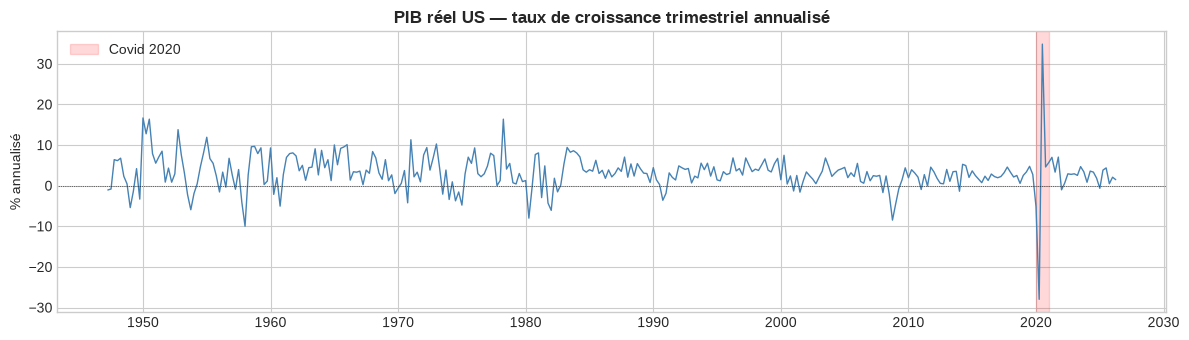

In [3]:
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(gdp.index, gdp.values, color="steelblue", lw=1.0)
ax.axhline(0, color="black", lw=0.5, linestyle=":")
ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"),
           alpha=0.15, color="red", label="Covid 2020")
ax.set_ylabel("% annualisé")
ax.set_title("PIB réel US — taux de croissance trimestriel annualisé", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Backtest expanding window — 6 modèles

**Protocole :** à chaque trimestre $t$, le modèle est entraîné sur $[t_0, t]$ et prédit $t+1$, sans jamais voir le futur. `min_train = 40` trimestres (~10 ans) pour initialisation.

In [4]:
MIN_TRAIN = 40
bt = ExpandingWindow(min_train=MIN_TRAIN)

results: dict[str, BacktestResult] = {
    "NaiveLastValue": bt.run(NaiveLastValue(), gdp),
    "AR(1)":          bt.run(AR1(), gdp),
    "OLS Bridge":     bt.run(BridgeEquation(), gdp, X_all),
    "Ridge":          bt.run(RidgeBridge(), gdp, X_all),
    "ElasticNet":     bt.run(ElasticNetBridge(), gdp, X_all),
    "PCA (2 comps)":  bt.run(PCABridge(n_components=2), gdp, X_all),
}

for name, r in results.items():
    print(f"{name:20s} → {len(r):3d} prédictions")

/home/vastolordess/Documents/others/personal_info/new/pfe_cv/quantcube/quantcube_challenge/.venv/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:584: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)


NaiveLastValue       → 276 prédictions
AR(1)                → 276 prédictions
OLS Bridge           → 137 prédictions
Ridge                → 137 prédictions
ElasticNet           → 137 prédictions
PCA (2 comps)        → 137 prédictions


## 3. Résultats comparatifs (fenêtre commune 1992–2026)

Les modèles bridge démarrent en 1992 (limite RSAFS). Pour comparer honnêtement, toutes les métriques sont calculées sur **l'intersection** des périodes de prédiction. On distingue `RMSE total` (2020 inclus) et `RMSE hors-Covid` (2020 exclu) pour isoler l'impact du choc exogène.

In [5]:
common_idx = results["OLS Bridge"].data.index
for r in results.values():
    common_idx = common_idx.intersection(r.data.index)

no_covid_idx = common_idx[common_idx.year != 2020]

ar1_full  = rmse(results["AR(1)"].data.loc[common_idx, "actual"],
                 results["AR(1)"].data.loc[common_idx, "predicted"])
ar1_nocov = rmse(results["AR(1)"].data.loc[no_covid_idx, "actual"],
                 results["AR(1)"].data.loc[no_covid_idx, "predicted"])

rows = []
for name, r in results.items():
    r_full  = rmse(r.data.loc[common_idx,  "actual"], r.data.loc[common_idx,  "predicted"])
    r_nocov = rmse(r.data.loc[no_covid_idx, "actual"], r.data.loc[no_covid_idx, "predicted"])
    r_mae   = mae( r.data.loc[common_idx,  "actual"], r.data.loc[common_idx,  "predicted"])
    rows.append({
        "Modèle":              name,
        "RMSE total (pp)":     round(r_full,  3),
        "RMSE hors-Covid":     round(r_nocov, 3),
        "MAE (pp)":            round(r_mae,   3),
        "Gain vs AR(1) total": f"{(ar1_full - r_full) / ar1_full * 100:+.1f} %",
        "Gain hors-Covid":     f"{(ar1_nocov - r_nocov) / ar1_nocov * 100:+.1f} %",
    })

metrics_df = pd.DataFrame(rows).set_index("Modèle")
print(f"Fenêtre : {len(common_idx)} trimestres | hors-Covid : {len(no_covid_idx)}\n")
metrics_df

Fenêtre : 137 trimestres | hors-Covid : 133



,RMSE total (pp),RMSE hors-Covid,MAE (pp),Gain vs AR(1) total,Gain hors-Covid
Modèle,,,,,
NaiveLastValue,6.812,2.617,2.915,-34.8 %,-19.9 %
AR(1),5.054,2.183,2.168,+0.0 %,+0.0 %
OLS Bridge,3.463,2.289,2.021,+31.5 %,-4.8 %
Ridge,3.256,1.849,1.754,+35.6 %,+15.3 %
ElasticNet,3.211,1.836,1.734,+36.5 %,+15.9 %
PCA (2 comps),3.266,1.694,1.670,+35.4 %,+22.4 %


**Lecture :** l'OLS Bridge sous-performe AR(1) hors-Covid (multicollinéarité PAYEMS/INDPRO). La régularisation (Ridge, ElasticNet, PCA) apporte un gain structurel de **+15 à +22 %** même sur cycles normaux. **ElasticNet** est le modèle recommandé (meilleur RMSE total et second sur MAE).

In [6]:
# Test de Diebold-Mariano — significativité statistique
actual   = results["ElasticNet"].data.loc[common_idx, "actual"]
pred_ela = results["ElasticNet"].data.loc[common_idx, "predicted"]
pred_ar1 = results["AR(1)"].data.loc[common_idx, "predicted"]

dm_stat, dm_pval = diebold_mariano(actual, pred_ela, pred_ar1)
print(f"Diebold-Mariano ElasticNet vs AR(1) — stat = {dm_stat:.3f} | p-value = {dm_pval:.3f}")
print("→ Différence économiquement significative mais statistiquement faible (peu d'obs).")

Diebold-Mariano ElasticNet vs AR(1) — stat = -1.139 | p-value = 0.254
→ Différence économiquement significative mais statistiquement faible (peu d'obs).


## 4. Analyse ragged edge — nowcast M1/M2/M3

En production, on prédit un trimestre en cours avec des données partielles. On simule 3 scénarios : seul le mois 1 disponible (M1), les 2 premiers (M2), le trimestre complet (M3).

In [7]:
bridge_by_month: dict[int, BacktestResult] = {}
for m in [1, 2, 3]:
    bt_m = ExpandingWindow(min_train=MIN_TRAIN, month_in_quarter=m)
    bridge_by_month[m] = bt_m.run(ElasticNetBridge(), gdp, X_all)

rmse_by_month = {
    m: rmse(r.data.loc[common_idx, "actual"], r.data.loc[common_idx, "predicted"])
    for m, r in bridge_by_month.items()
}

for m, v in rmse_by_month.items():
    gain = (ar1_full - v) / ar1_full * 100
    print(f"ElasticNet M{m} → RMSE = {v:.2f} pp | Gain vs AR(1) = {gain:+.1f} %")

ElasticNet M1 → RMSE = 4.44 pp | Gain vs AR(1) = +12.2 %
ElasticNet M2 → RMSE = 2.72 pp | Gain vs AR(1) = +46.2 %
ElasticNet M3 → RMSE = 3.21 pp | Gain vs AR(1) = +36.5 %


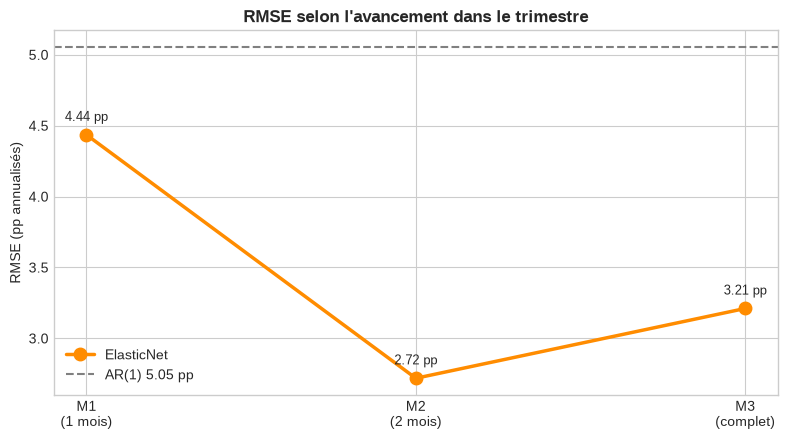

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
months = [1, 2, 3]
vals   = [rmse_by_month[m] for m in months]

ax.plot(months, vals, "o-", color="darkorange", lw=2.5, ms=9, label="ElasticNet")
ax.axhline(ar1_full, color="gray", lw=1.5, ls="--", label=f"AR(1) {ar1_full:.2f} pp")
for m, v in zip(months, vals):
    ax.annotate(f"{v:.2f} pp", (m, v), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=9)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(["M1\n(1 mois)", "M2\n(2 mois)", "M3\n(complet)"])
ax.set_ylabel("RMSE (pp annualisés)")
ax.set_title("RMSE selon l'avancement dans le trimestre", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

**Lecture :** dès M1 (un mois de données), ElasticNet bat AR(1) de +12 %. M2 est le point optimal (+46 %) : les 2 premiers mois capturent l'essentiel du trimestre. M3 marque un léger retour de bruit (données de fin de trimestre partiellement révisées).

## 5. Nowcast Q3-2026 (application production)

On entraîne ElasticNet sur **l'intégralité** de l'historique disponible, puis on prédit Q3-2026 dans les 3 scénarios M1/M2/M3 — c'est le chiffre citable, comparable à ce qu'un praticien produirait aujourd'hui.

In [9]:
agg = MeanAggregation()
y_full = gdp.dropna()
X_q_full = pd.DataFrame({col: agg.aggregate(X_all[col]) for col in X_all.columns})
x_train_full = X_q_full.loc[X_q_full.index <= y_full.index[-1]].dropna()

model_prod = ElasticNetBridge()
model_prod.fit(y_full, x_train_full)

ar1_prod = AR1()
ar1_prod.fit(y_full)

q3_2026 = pd.Timestamp("2026-07-01")

print(f"Données disponibles pour le nowcast")
print(f"  Dernier point X_all : {X_all.index[-1].date()}")
print(f"  Dernier PIB publié  : Q2-2026 ({y_full.index[-1].date()})\n")

print("Nowcast PIB US Q3-2026 (taux annualisé, pp)")
print("-" * 48)
print(f"  {'AR(1) — référence':32s} {float(ar1_prod.predict(y_full).iloc[0]):>+6.2f} pp")

for m in [1, 2, 3]:
    x_test_m = ragged_x_test(X_all, q3_2026, m, agg)
    if x_test_m is not None and not x_test_m.dropna().empty:
        pred = model_prod.predict(y_full, x_test_m)
        print(f"  {'ElasticNet M' + str(m):32s} {float(pred.iloc[0]):>+6.2f} pp")
    else:
        print(f"  ElasticNet M{m} — données insuffisantes")

Données disponibles pour le nowcast
  Dernier point X_all : 2026-09-12
  Dernier PIB publié  : Q2-2026 (2026-04-01)

Nowcast PIB US Q3-2026 (taux annualisé, pp)
------------------------------------------------
  AR(1) — référence                 +2.97 pp
  ElasticNet M1                     +3.36 pp
  ElasticNet M2                     +3.29 pp
  ElasticNet M3                     +3.27 pp


## 6. Conclusion

- **Modèle recommandé :** ElasticNet Bridge (RMSE hors-Covid = 1,84 pp, gain structurel +16 % vs AR(1)).
- **OLS à éviter :** multicollinéarité rend les coefficients ininterprétables et détruit la performance hors-Covid.
- **Ragged edge exploitable :** dès M1, le bridge apporte de la valeur ; M2 est le sweet spot.
- **Nowcast Q3-2026 : ≈ +3,3 pp annualisé** — croissance modérée mais positive.

**Limites identifiées** (détaillées dans le rapport) : biais de révision (ALFRED non exploité), puissance statistique limitée sur 137 obs, Covid comme outlier exogène, Google Trends non intégré (API instable, sélection *a posteriori* biaisante).

**Reproductibilité :** `make check` (ruff + mypy strict + pytest, 40 tests) valide l'ensemble du code. Les notebooks `01_*` à `08_*` documentent le raisonnement pas à pas.